In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df=yf.download("SPY", start="1990-01-01", end="2021-01-01")
print(df.head())

In [ ]:
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

import matplotlib as plt 


In [ ]:
import matplotlib.pyplot as plt
plt.plot(df['Close'])


In [ ]:
df['MA']=df['Close'].rolling(window=50).mean()
plt.plot(df['MA'])

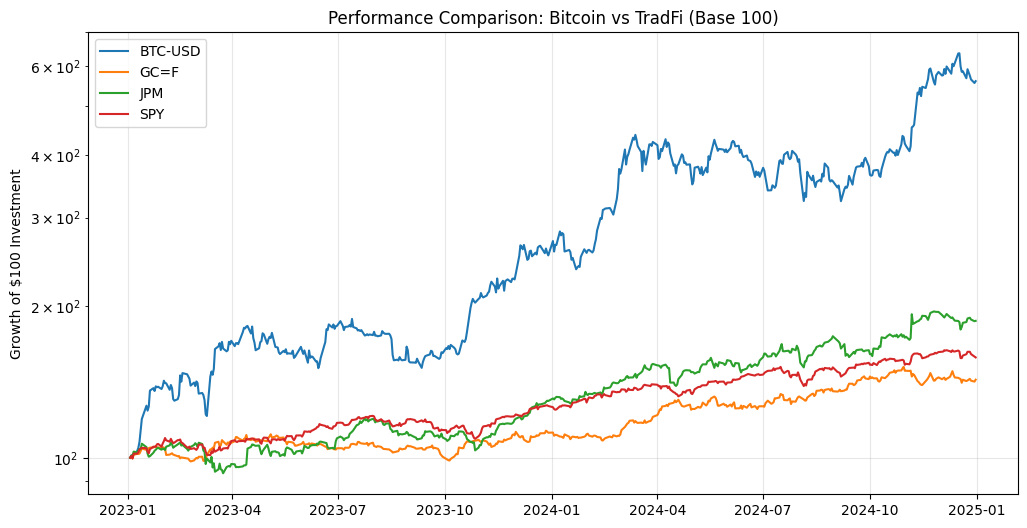

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

# 1. Setup variables
TICKERS = ['SPY', 'GC=F', 'JPM', 'BTC-USD'] 
START_DATE = "2023-01-01" 
END_DATE = "2025-01-01"

# 2. Download data
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, progress=False)

# Robust data extraction logic
if isinstance(raw.columns, pd.MultiIndex):
    if 'Adj Close' in raw.columns.levels[0]:
        data = raw['Adj Close']
    elif 'Close' in raw.columns.levels[0]:
        data = raw['Close']
    else:
        data = raw.xs(raw.columns.levels[0][0], axis=1, level=0)
else:
    if 'Adj Close' in raw.columns:
        data = raw['Adj Close']
    else:
        data = raw

# --- CRITICAL FIX ---
# Drop rows where ANY ticker is missing data. 
# This auto-adjusts the start date to Sept 2014 (when BTC data starts).
data = data.dropna()

# 3. Normalize data (Rebase to 100)
# This calculates the growth of a $100 investment
normalized_df = (data / data.iloc[0]) * 100

# 4. Plot the graph
plt.figure(figsize=(12, 6))

plt.plot(normalized_df)

# Add labels and style
plt.title(f'Performance Comparison: Bitcoin vs TradFi (Base 100)')
plt.legend(normalized_df.columns) 
plt.ylabel('Growth of $100 Investment')
plt.grid(True, alpha=0.3)

# OPTIONAL: Logarithmic scale
# Bitcoin moves exponentially. A linear scale makes SPY/JPM look flat.
# Uncomment the line below to see relative performance better:
plt.yscale('log') 

plt.show()

In [ ]:
# 1. Setup variables
TICKER = 'SPY'
WINDOW = 200

# 2. Download data
df = yf.download(TICKER,start="1990-01-01", end="2021-01-01")

# 3. Calculate Moving Average
# (Using 'Close' with a capital C, because yfinance requires it)
df['MA'] = df['Close'].rolling(WINDOW).mean()

# 4. Plot the graph
plt.figure(figsize=(10, 5)) # Optional: Makes the chart wider/clearer
plt.plot(df['Close'])
plt.plot(df['MA'])
plt.legend([f'{TICKER} Close Price', f'{WINDOW} Moving Average'])
plt.title(f'{TICKER} Close vs. Moving Average')
plt.show()

In [ ]:
df.columns = df.columns.get_level_values(0)
def add_ma_strategy(df):
    df['Strategy'] = np.where(df['Close'] > df['MA'], 1, -1)
    return df
df = add_ma_strategy(df)
df['asset_cumulative'] = np.cumprod(1 + df['Close'].pct_change()) - 1
df['strategy_cumulative'] = np.cumprod(1 + df['Close'].pct_change() * df['Strategy'].shift()) - 1

In [ ]:
plt.plot(df['asset_cumulative'])
plt.plot(df['strategy_cumulative'])

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TICKER = 'SPY'
WINDOW = 200

def getdata():
    df = yf.download(TICKER, start="1990-01-01", end="2021-01-01")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df['MA'] = df['Close'].rolling(WINDOW).mean()
    return df

def add_ma_strategy(df):
    df['Signal'] = np.where(df['Close'] > df['MA'], 1, -1)
    df['Strategy'] = df['Signal'].shift(1)
    return df

def backtest(df):
    df['asset_cumulative'] = (1 + df['Close'].pct_change()).cumprod() - 1
    df['strategy_cumulative'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() - 1
    return df

def main():
    df = getdata()
    df = add_ma_strategy(df)
    df = backtest(df)
    return df

df = main()
print(df.tail())

plt.figure(figsize=(12, 6))
plt.plot(df['asset_cumulative'], label='Asset Cumulative Return')
plt.plot(df['strategy_cumulative'], label='Strategy Cumulative Return')
plt.legend()
plt.title(f'{TICKER} Backtest Results')
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TICKER = 'SPY'

# --- PARAMETERS ---
EMA_LEN = 200      # Trend Filter
RSI_LEN = 14       # Momentum
ATR_LEN = 14       # Volatility
VOL_LEN = 20       # Volume Average

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_atr(df, period=14):
    high_low = df['High'] - df['Low']
    high_close = np.abs(df['High'] - df['Close'].shift())
    low_close = np.abs(df['Low'] - df['Close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = ranges.max(axis=1)
    return true_range.rolling(window=period).mean()

def getdata():
    # Added High/Low/Volume columns which are needed for ATR and Volume
    df = yf.download(TICKER, start="1990-01-01", end="2026-01-01")
    
    # Fix for multi-level columns in newer yfinance versions
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    # 1. EMA (Exponential Moving Average)
    df['EMA'] = df['Close'].ewm(span=EMA_LEN, adjust=False).mean()
    
    # 2. RSI (Relative Strength Index)
    df['RSI'] = calculate_rsi(df['Close'], RSI_LEN)
    
    # 3. ATR (Average True Range)
    df['ATR'] = calculate_atr(df, ATR_LEN)
    df['ATR_MA'] = df['ATR'].rolling(window=20).mean() # Baseline for volatility
    
    # 4. Volume SMA
    df['Vol_MA'] = df['Volume'].rolling(window=VOL_LEN).mean()
    
    # Drop NaN values created by indicators
    df.dropna(inplace=True)
    return df

def add_strategy(df):
    # --- STRATEGY LOGIC ---
    # Condition 1: Trend is UP (Price > EMA)
    c_trend = df['Close'] > df['EMA']
    
    # Condition 2: Pullback Opportunity (RSI < 55) - Buying the dip
    c_rsi = df['RSI'] < 55
    
    # Condition 3: High Volume (Volume > Average Volume)
    c_vol = df['Volume'] > df['Vol_MA']
    
    # Condition 4: Volatility is expanding (ATR > Average ATR)
    c_atr = df['ATR'] > df['ATR_MA']

    # --- SIGNAL GENERATION ---
    # 1 = Buy, 0 = Hold/Neutral (We use 0 instead of -1 for Long Only strategies usually)
    # But to match your previous code structure: 1 = Long, -1 = Short/Cash
    
    # Generate raw signals
    df['Signal'] = np.where(c_trend & c_rsi & c_vol & c_atr, 1, 0)
    
    # If Signal is 0, check if we should stay in trade or exit
    # Simple exit: If Price < EMA, go to -1 (Sell). Otherwise hold previous position.
    # This vectorization trick propagates the position:
    df['Position'] = np.where(df['Close'] < df['EMA'], 0, np.nan) # Exit condition
    df['Position'] = np.where(df['Signal'] == 1, 1, df['Position']) # Entry condition
    df['Position'] = df['Position'].ffill().fillna(0) # Forward fill holds the position
    
    # Shift by 1 to avoid look-ahead bias (we trade at Open of NEXT day based on TODAY's signal)
    df['Strategy_Shifted'] = df['Position'].shift(1)
    
    return df

def backtest(df):
    # Calculate daily returns
    df['Returns'] = df['Close'].pct_change()
    
    # Asset Cumulative Return (Buy and Hold)
    df['asset_cumulative'] = (1 + df['Returns']).cumprod() - 1
    
    # Strategy Cumulative Return
    # We use Strategy_Shifted to multiply against today's return
    df['strategy_cumulative'] = (1 + df['Returns'] * df['Strategy_Shifted']).cumprod() - 1
    
    return df

def main():
    df = getdata()
    df = add_strategy(df)
    df = backtest(df)
    return df

# Run and Plot
df = main()
print(df[['Close', 'EMA', 'RSI', 'Signal', 'Position']].tail())

plt.figure(figsize=(12, 6))
plt.plot(df['asset_cumulative'], label='Buy & Hold (SPY)', alpha=0.5)
plt.plot(df['strategy_cumulative'], label='ATR-RSI-EMA Strategy', linewidth=2)
plt.legend()
plt.title(f'{TICKER} Backtest: Hybrid Strategy')
plt.grid(True)
plt.show()

--- RESULTS (BTC-USD) ---
Buy & Hold:
  Final Value:    $64,075
  Total Return:   540.75%
  Max Drawdown:   -81.53%
------------------------------
AMD Strategy:
  Final Value:    $138,073
  Total Return:   1,280.73%
  Max Drawdown:   -45.47%


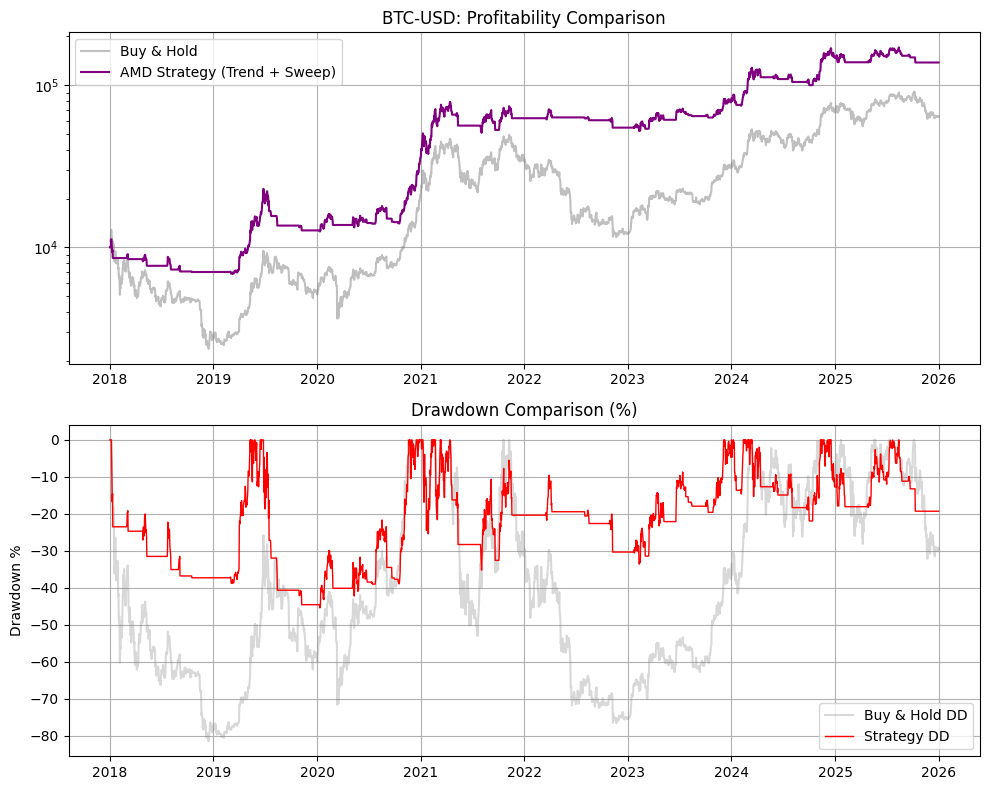

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup variables
TICKER = 'BTC-USD'
START_DATE = "2018-01-01"
END_DATE = "2026-01-01"
INITIAL_CAPITAL = 10000
EMA_PERIOD = 50 

# 2. Download data
df = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 3. Calculate Indicators
df['EMA'] = df['Close'].ewm(span=EMA_PERIOD, adjust=False).mean()

# Liquidity Levels (Previous Day)
df['Prev_High'] = df['High'].shift(1)
df['Prev_Low'] = df['Low'].shift(1)

# 4. Strategy Logic
positions = []
in_position = False

for index, row in df.iterrows():
    price = row['Close']
    low = row['Low']
    prev_low = row['Prev_Low']
    ema = row['EMA']
    
    # EXIT RULE: Trend Break (Distribution Complete)
    if in_position:
        if price < ema:
            in_position = False
            positions.append(0)
        else:
            positions.append(1) # Hold
            
    # ENTRY RULE: Trend + Manipulation (Accumulation)
    else:
        # Context: Bull Trend (Price > EMA 50)
        if price > ema:
            # Trigger: Liquidity Grab (Manipulation)
            # Price sweeps below previous low but closes above it (SFP)
            liquidity_grab = (low < prev_low) and (price > prev_low)
            
            if liquidity_grab:
                in_position = True
                positions.append(1)
            else:
                positions.append(0) # Wait for the grab
        else:
            positions.append(0) # Bear market

df['Position'] = positions

# 5. Returns & Drawdowns

# --- STRATEGY ---
df['Strat_Return'] = df['Position'].shift(1) * df['Close'].pct_change()
df['Strat_Curve'] = (1 + df['Strat_Return'].fillna(0)).cumprod() * INITIAL_CAPITAL
df['Strat_Peak'] = df['Strat_Curve'].cummax()
df['Strat_Drawdown'] = (df['Strat_Curve'] - df['Strat_Peak']) / df['Strat_Peak']
strat_dd = df['Strat_Drawdown'].min() * 100
final_strat = df['Strat_Curve'].iloc[-1]
# Total Return %
strat_pct_ret = ((final_strat - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100

# --- BUY & HOLD (BENCHMARK) ---
df['BH_Return'] = df['Close'].pct_change()
df['BH_Curve'] = (1 + df['BH_Return']).cumprod() * INITIAL_CAPITAL
df['BH_Peak'] = df['BH_Curve'].cummax()
df['BH_Drawdown'] = (df['BH_Curve'] - df['BH_Peak']) / df['BH_Peak']
bh_dd = df['BH_Drawdown'].min() * 100
final_bh = df['BH_Curve'].iloc[-1]
# Total Return %
bh_pct_ret = ((final_bh - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100

print(f"--- RESULTS ({TICKER}) ---")
print(f"Buy & Hold:")
print(f"  Final Value:    ${final_bh:,.0f}")
print(f"  Total Return:   {bh_pct_ret:,.2f}%")
print(f"  Max Drawdown:   {bh_dd:.2f}%")
print("-" * 30)
print(f"AMD Strategy:")
print(f"  Final Value:    ${final_strat:,.0f}")
print(f"  Total Return:   {strat_pct_ret:,.2f}%")
print(f"  Max Drawdown:   {strat_dd:.2f}%")

plt.figure(figsize=(10, 8))

# Subplot 1: Value
plt.subplot(2, 1, 1)
plt.plot(df['BH_Curve'], label='Buy & Hold', color='gray', alpha=0.5)
plt.plot(df['Strat_Curve'], label='AMD Strategy (Trend + Sweep)', color='purple')
plt.yscale('log')
plt.title(f'{TICKER}: Profitability Comparison')
plt.legend()
plt.grid(True)

# Subplot 2: Drawdowns
plt.subplot(2, 1, 2)
plt.plot(df.index, df['BH_Drawdown']*100, label='Buy & Hold DD', color='gray', alpha=0.3)
plt.plot(df.index, df['Strat_Drawdown']*100, label='Strategy DD', color='red', linewidth=1)
plt.title('Drawdown Comparison (%)')
plt.ylabel('Drawdown %')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

def linear_approximation(x0, x):
    # Fixed: Removed 'AC' from the end of the line
    return x0**2 + 2*x0*(x - x0)

def plot_approximation(x0):
    # Dynamic x-range centered around the selected x0
    x = np.linspace(x0 - 5, x0 + 5, 400)
    
    y = x**2
    y_lin = linear_approximation(x0, x)
    
    # Fixed: Removed 'A' from the end of the line
    plt.figure(figsize=(8, 6))
    
    # Plot the main function
    plt.plot(x, y, label=r'$f(x)=x^2$', color='blue', linewidth=2)
    
    # Plot the tangent line (linear approximation)
    plt.plot(x, y_lin, label=f'Linear Approx at $x_0={x0}$', linestyle='--', color='red', linewidth=2)
    
    # Plot the point of tangency
    plt.scatter([x0], [x0**2], color='black', zorder=5)

    plt.title(r'Linear Approximation of $x^2$')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Optional: Fix y-limits slightly to prevent "jumping" axes if desired
    # plt.ylim(min(y), max(y)) 
    
    plt.show()

# Run the interaction
interact(plot_approximation, x0=(-10, 10, 1));

interactive(children=(IntSlider(value=0, description='x0', max=10, min=-10), Output()), _dom_classes=('widget-…